In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_moons
data = make_moons(n_samples=1000,noise=0.1)
df = pd.DataFrame({'X':data[0][:,0],'Y':data[0][:,1],'class':data[1]})

In [3]:
df.head()

,X,Y,class
0,-0.676982,0.539151,0
1,0.559721,-0.423748,1
2,1.039261,-0.666162,1
3,0.727131,0.564420,0
4,0.605663,0.725058,0


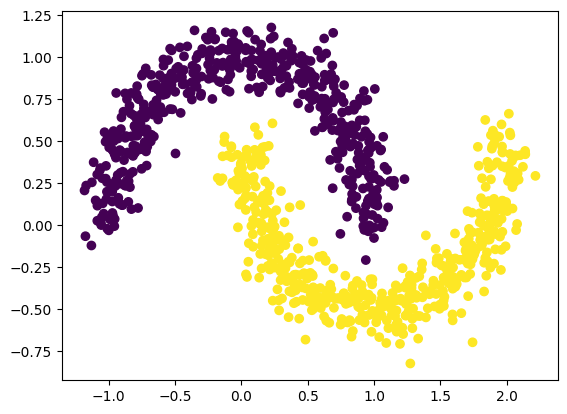

In [4]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [5]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [6]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [7]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.get_weights()

[array([[-0.2297717 ,  1.7367386 ,  0.33798376, -1.0666845 ,  1.3694485 ,
         -0.7705372 ,  1.810391  ,  0.95663124,  0.7579317 , -1.1428761 ],
        [ 1.6327417 , -0.6610507 , -0.96233475, -0.267739  ,  2.029356  ,
          0.3016049 , -0.39617503,  1.2032568 ,  0.978993  , -0.52742326]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.37934104,  0.06422006, -0.14448132,  0.3486668 , -0.13824616,
         -0.19116001,  0.44142544,  0.29472488, -0.22173609,  0.44705892],
        [-0.21506745,  0.2015653 ,  0.54313105,  0.10394081, -0.30287325,
         -0.24135989, -0.10174403, -0.0872809 , -0.4561456 , -0.3246377 ],
        [ 0.28294122,  0.7954435 ,  0.09694855, -0.42786974,  0.644728  ,
          0.07397217, -0.03475249, -0.38629112,  0.32909143, -0.48914996],
        [-0.43822426, -0.09393692,  0.44349268, -0.42969602, -0.123173  ,
         -0.19834536,  0.22372   ,  0.67349553, -0.22651431, -0.05384581],
        [-0.81287

In [9]:
initial_weights = model.get_weights()

In [11]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [12]:
model.set_weights(initial_weights)

In [13]:
model.get_weights()

[array([[-0.9424567 ,  0.00201174,  0.66948336,  0.25037712, -0.6041583 ,
         -0.01876044, -0.12256963,  0.0513835 , -0.08411962, -0.4188561 ],
        [-1.9477273 , -0.1372179 ,  0.93983144, -0.22982065,  0.5345381 ,
         -1.3020573 ,  0.20850998, -1.5739688 , -0.83176607,  0.33840436]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.36457962,  0.3007425 ,  0.04660535,  0.23026973, -0.11571185,
          0.16062267, -0.14410765,  0.01885865,  0.02277095, -0.37981844],
        [ 0.12722538,  0.245127  ,  0.680486  ,  0.5797681 , -0.3964144 ,
          0.1635233 ,  0.5052303 , -0.6427324 ,  0.53108394,  0.22839484],
        [-0.12122322,  0.49287134, -0.27549276,  0.32297522, -0.07123718,
         -0.7180322 , -0.27849928, -0.00451605,  0.35780042,  0.34696117],
        [-0.23207906, -0.06404496,  0.31118715,  0.28837478,  0.07055624,
          0.8902354 ,  0.11284943,  0.06016136, -0.17736405, -0.14365357],
        [ 0.51533

In [14]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [15]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2560 - loss: 0.7241 - val_accuracy: 0.4400 - val_loss: 0.6934
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4547 - loss: 0.6862 - val_accuracy: 0.6550 - val_loss: 0.6514
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7223 - loss: 0.6437 - val_accuracy: 0.7450 - val_loss: 0.5888
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7582 - loss: 0.5808 - val_accuracy: 0.7500 - val_loss: 0.5218
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8055 - loss: 0.5033 - val_accuracy: 0.8750 - val_loss: 0.4804
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8834 - loss: 0.4595 - val_accuracy: 0.8800 - val_loss: 0.4610
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8689 - loss: 0.4382 - val_accuracy: 0.8850 - val_loss: 0.4427
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8993 - loss: 0.3930 - val_accuracy: 0.8650 - v

In [16]:
model.get_weights()

[array([[-1.3595601 ,  0.2685572 ,  0.5458932 ,  0.6424528 , -0.4785006 ,
         -0.05908953, -0.48689938,  0.07923587, -0.05316301, -0.92986214],
        [-1.5470018 ,  0.01031589,  1.1579847 , -0.1460654 ,  0.70978904,
         -1.2973789 ,  0.32774103, -1.7200263 , -1.220087  ,  0.38005364]],
       dtype=float32),
 array([ 0.47315   , -0.23440711,  0.02390887,  0.0156971 , -0.2985092 ,
        -0.04002965,  0.8477152 , -0.11501189,  0.05850596, -0.23276512],
       dtype=float32),
 array([[ 0.08318482,  0.6651432 ,  0.03814108,  0.38105282,  0.39432117,
          0.28148025, -0.19494738,  0.24538349,  0.06052752, -0.2195775 ],
        [-0.27214944,  0.09708394,  0.9924452 ,  0.35708642, -0.5678827 ,
          0.65659714,  0.37991565, -1.1655372 ,  0.16679654,  0.99803036],
        [-0.398168  ,  0.6980482 , -0.16894014,  0.4580039 , -0.06238218,
         -0.27957782, -0.32580343,  0.04849264,  0.22427045,  0.8969304 ],
        [-0.73795027,  0.04693477,  0.41236642,  0.24595304, 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


<Axes: >

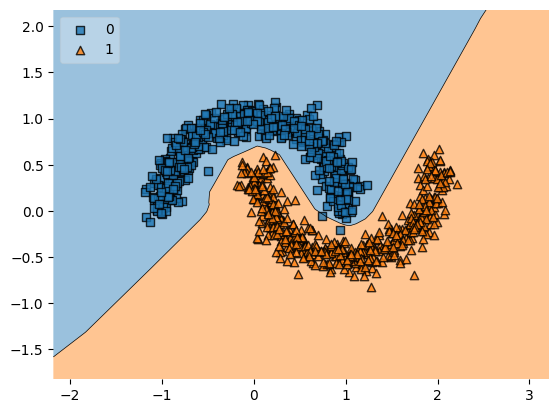

In [17]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

In [18]:
(np.random.randn(10,10)*0.01).min()

np.float64(-0.024613376037661606)

In [19]:
(np.random.randn(10,10)*0.01).max()

np.float64(0.027249611859204114)